<a href="https://colab.research.google.com/github/Gsmtz29/act1-AAA/blob/main/act1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder

# Configuración visual para las gráficas
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

# Carga del dataset original
df_raw = pd.read_csv('StudentPerformanceFactors.csv')

print("✅ Librerías cargadas y dataset importado correctamente.")

✅ Librerías cargadas y dataset importado correctamente.


In [ ]:
# Registramos los metadatos requeridos
metadatos = {
    "Nombre del dataset": "Student Performance Factors Dataset",
    "Fuente": "Kaggle",
    "Liga de acceso": "https://www.kaggle.com/datasets/mosapabdelghany/student-performance-factors-dataset",
    "Fecha de consulta": "15 de agosto de 2026",
    "Última actualización reportada": "2025",
    "Variable objetivo propuesta": "Exam_Score (Numérica continua)",
    "Tipo de ML": "Aprendizaje Supervisado - Regresión"
}

for clave, valor in metadatos.items():
    print(f" {clave}: {valor}")

 Nombre del dataset: Student Performance Factors Dataset
 Fuente: Kaggle
 Liga de acceso: https://www.kaggle.com/datasets/mosapabdelghany/student-performance-factors-dataset
 Fecha de consulta: 15 de agosto de 2026
 Última actualización reportada: 2025
 Variable objetivo propuesta: Exam_Score (Numérica continua)
 Tipo de ML: Aprendizaje Supervisado - Regresión


In [ ]:
print(f"Filas totales: {df_raw.shape[0]}")
print(f"Columnas totales: {df_raw.shape[1]}")

print("\n--- RESUMEN DE ESTRUCTURA Y NULOS ---")
resumen_inicial = pd.DataFrame({
    'Tipo_Dato': df_raw.dtypes,
    'Valores_Faltantes': df_raw.isnull().sum(),
    'Porcentaje_Nulos (%)': (df_raw.isnull().sum() / len(df_raw)) * 100,
    'Valores_Unicos': df_raw.nunique()
})
display(resumen_inicial)

total_duplicados_inicial = df_raw.duplicated().sum()
print(f"\nRegistros duplicados detectados al inicio: {total_duplicados_inicial}")

print("\n--- MUESTRA DE REGISTROS ---")
display(df_raw.head())

print("\n--- ESTADÍSTICAS DESCRIPTIVAS INICIALES ---")
display(df_raw.describe(include='all').T)

Filas totales: 6607
Columnas totales: 20

--- RESUMEN DE ESTRUCTURA Y NULOS ---


,Tipo_Dato,Valores_Faltantes,Porcentaje_Nulos (%),Valores_Unicos
Hours_Studied,int64,0,0.000000,41
Attendance,int64,0,0.000000,41
Parental_Involvement,object,0,0.000000,3
Access_to_Resources,object,0,0.000000,3
Extracurricular_Activities,object,0,0.000000,2
Sleep_Hours,int64,0,0.000000,7
Previous_Scores,int64,0,0.000000,51
Motivation_Level,object,0,0.000000,3
Internet_Access,object,0,0.000000,2
Tutoring_Sessions,int64,0,0.000000,9



Registros duplicados detectados al inicio: 0

--- MUESTRA DE REGISTROS ---


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70



--- ESTADÍSTICAS DESCRIPTIVAS INICIALES ---


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Hours_Studied,6607.0,NaN,NaN,NaN,19.975329,5.990594,1.0,16.0,20.0,24.0,44.0
Attendance,6607.0,NaN,NaN,NaN,79.977448,11.547475,60.0,70.0,80.0,90.0,100.0
Parental_Involvement,6607,3,Medium,3362,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Access_to_Resources,6607,3,Medium,3319,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Extracurricular_Activities,6607,2,Yes,3938,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sleep_Hours,6607.0,NaN,NaN,NaN,7.02906,1.46812,4.0,6.0,7.0,8.0,10.0
Previous_Scores,6607.0,NaN,NaN,NaN,75.070531,14.399784,50.0,63.0,75.0,88.0,100.0
Motivation_Level,6607,3,Medium,3351,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Internet_Access,6607,2,Yes,6108,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Tutoring_Sessions,6607.0,NaN,NaN,NaN,1.493719,1.23057,0.0,1.0,1.0,2.0,8.0


In [ ]:
# Hacemos una copia para no alterar el dataframe original
df_clean = df_raw.copy()

# 1. Limpieza de nombres de columnas
df_clean.columns = df_clean.columns.str.strip()

# 2. Eliminación de duplicados
duplicados_detectados = df_clean.duplicated().sum()
df_clean = df_clean.drop_duplicates()
print(f"🧹 Se eliminaron {duplicados_detectados} registros duplicados.")

# 3. Limpieza de espacios en blanco en columnas de texto
cat_cols = df_clean.select_dtypes(include=['object']).columns
for col in cat_cols:
    df_clean[col] = df_clean[col].astype(str).str.strip()

# 4. Imputación de valores faltantes por la Moda (para categóricas)
columnas_con_nulos = ['Teacher_Quality', 'Parental_Education_Level', 'Distance_from_Home']

for col in columnas_con_nulos:
    if col in df_clean.columns:
        # Remplazamos strings 'nan' que pudieron surgir del strip()
        df_clean[col] = df_clean[col].replace('nan', np.nan)

        # Calculamos la moda y rellenamos
        moda_val = df_clean[col].mode()[0]
        df_clean[col] = df_clean[col].fillna(moda_val)

print("✅ Limpieza inicial completada. Nulos actuales por columna:")
print(df_clean.isnull().sum().sum(), "nulos restantes.")

🧹 Se eliminaron 0 registros duplicados.
✅ Limpieza inicial completada. Nulos actuales por columna:
0 nulos restantes.


In [ ]:
# Comprobación explícita antes/después
print("Nulos antes de limpiar (df_raw)")
print(df_raw[['Teacher_Quality', 'Parental_Education_Level', 'Distance_from_Home']].isnull().sum())

print("\nNulos despues de limpiar (df_clean)")
print(df_clean[['Teacher_Quality', 'Parental_Education_Level', 'Distance_from_Home']].isnull().sum())

Nulos antes de limpiar (df_raw)
Teacher_Quality             78
Parental_Education_Level    90
Distance_from_Home          67
dtype: int64

Nulos despues de limpiar (df_clean)
Teacher_Quality             0
Parental_Education_Level    0
Distance_from_Home          0
dtype: int64


--- MEDIDAS DESCRIPTIVAS: Exam_Score ---
Media: 67.24
Mediana: 67.00
Desviación Estándar: 3.89
Mínimo: 55.00
Máximo: 101.00


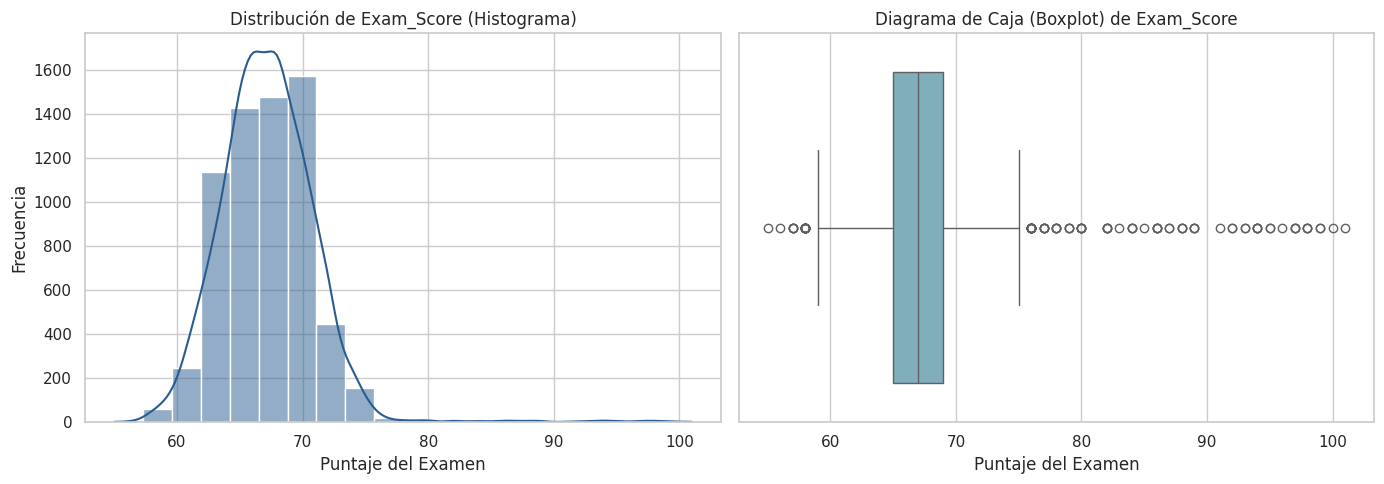

In [ ]:
score = df_clean['Exam_Score']

# Estadísticas descriptivas de la variable objetivo
print("--- MEDIDAS DESCRIPTIVAS: Exam_Score ---")
print(f"Media: {score.mean():.2f}")
print(f"Mediana: {score.median():.2f}")
print(f"Desviación Estándar: {score.std():.2f}")
print(f"Mínimo: {score.min():.2f}")
print(f"Máximo: {score.max():.2f}")

# Visualización gráfica
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma + KDE
sns.histplot(score, kde=True, ax=axes[0], color='#2b5c8f', bins=20)
axes[0].set_title("Distribución de Exam_Score (Histograma)")
axes[0].set_xlabel("Puntaje del Examen")
axes[0].set_ylabel("Frecuencia")

# Boxplot
sns.boxplot(x=score, ax=axes[1], color='#76b5c5')
axes[1].set_title("Diagrama de Caja (Boxplot) de Exam_Score")
axes[1].set_xlabel("Puntaje del Examen")

plt.tight_layout()
plt.show()

/tmp/ipykernel_678/1082812343.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x='Parental_Involvement', ax=axes[1,0], palette='Set2', order=['Low', 'Medium', 'High'])
/tmp/ipykernel_678/1082812343.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='School_Type', y='Exam_Score', ax=axes[1,1], palette='Pastel1')


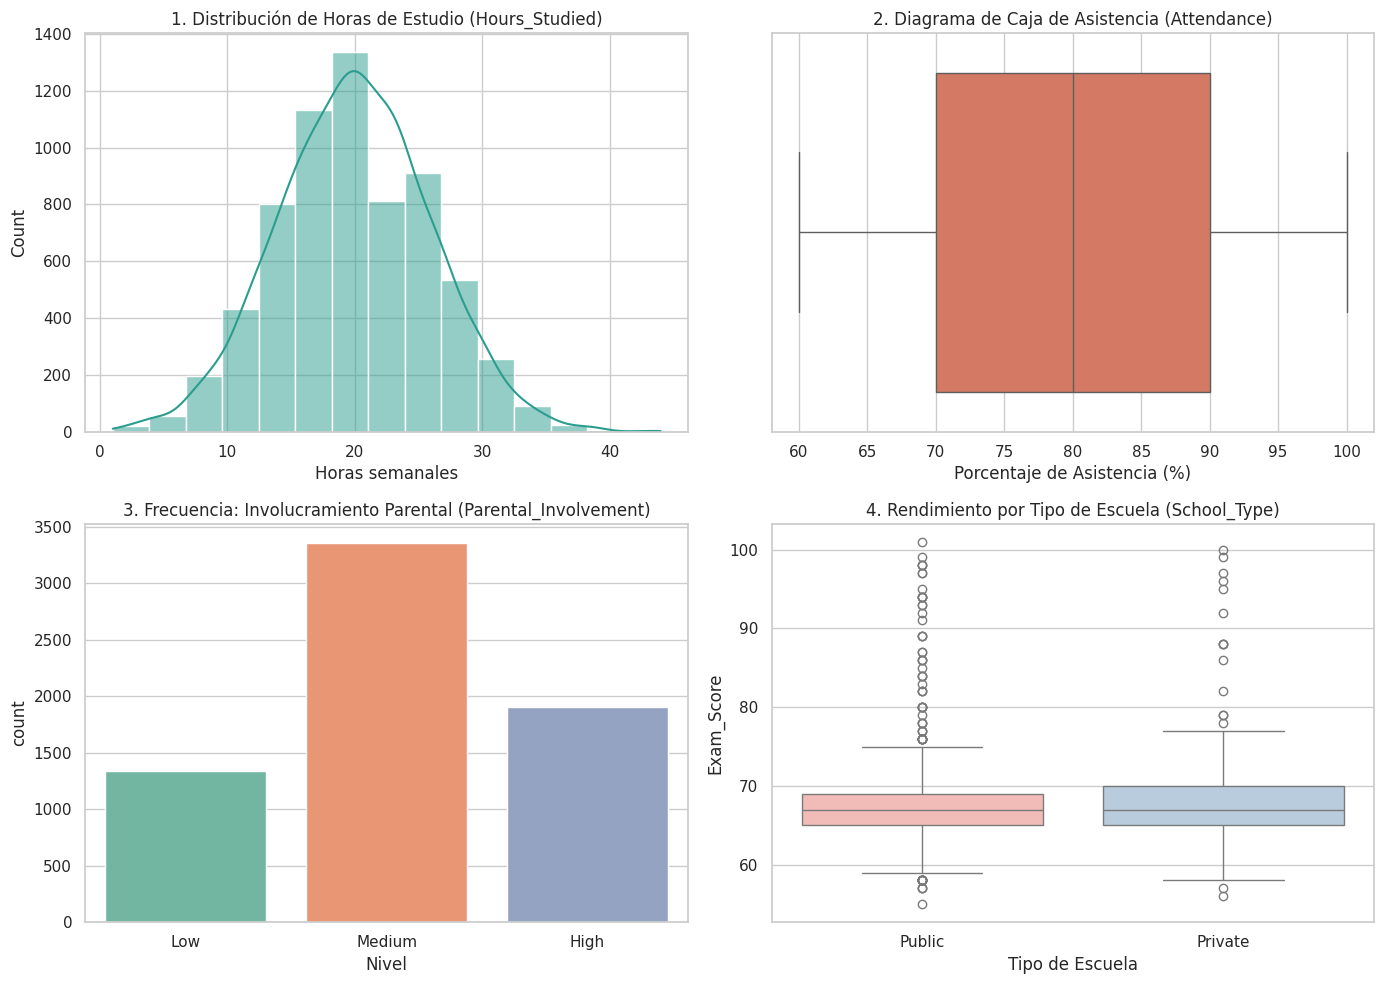

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Numérica 1: Hours_Studied
sns.histplot(df_clean['Hours_Studied'], ax=axes[0,0], kde=True, color='#2a9d8f', bins=15)
axes[0,0].set_title("1. Distribución de Horas de Estudio (Hours_Studied)")
axes[0,0].set_xlabel("Horas semanales")

# 2. Numérica 2: Attendance
sns.boxplot(x=df_clean['Attendance'], ax=axes[0,1], color='#e76f51')
axes[0,1].set_title("2. Diagrama de Caja de Asistencia (Attendance)")
axes[0,1].set_xlabel("Porcentaje de Asistencia (%)")

# 3. Categórica 1: Parental_Involvement
sns.countplot(data=df_clean, x='Parental_Involvement', ax=axes[1,0], palette='Set2', order=['Low', 'Medium', 'High'])
axes[1,0].set_title("3. Frecuencia: Involucramiento Parental (Parental_Involvement)")
axes[1,0].set_xlabel("Nivel")

# 4. Categórica 2 vs Objetivo: School_Type vs Exam_Score
sns.boxplot(data=df_clean, x='School_Type', y='Exam_Score', ax=axes[1,1], palette='Pastel1')
axes[1,1].set_title("4. Rendimiento por Tipo de Escuela (School_Type)")
axes[1,1].set_xlabel("Tipo de Escuela")

plt.tight_layout()
plt.show()

In [ ]:
# Selección de columnas según su naturaleza
num_features = ['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 'Tutoring_Sessions']
ord_features = ['Parental_Involvement', 'Access_to_Resources', 'Motivation_Level']
nom_features = ['School_Type', 'Internet_Access', 'Gender']

# Pipelines de tratamiento por tipo de variable
num_pipeline = Pipeline(steps=[
    ('scaler', StandardScaler())
])

ord_pipeline = Pipeline(steps=[
    ('ordinal', OrdinalEncoder(categories=[
        ['Low', 'Medium', 'High'],  # Parental_Involvement
        ['Low', 'Medium', 'High'],  # Access_to_Resources
        ['Low', 'Medium', 'High']   # Motivation_Level
    ]))
])

nom_pipeline = Pipeline(steps=[
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
])

# ColumnTransformer general
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, num_features),
        ('ord', ord_pipeline, ord_features),
        ('nom', nom_pipeline, nom_features)
    ],
    remainder='drop'
)

# Separación de características (X) y variable objetivo (y)
X = df_clean[num_features + ord_features + nom_features]
y = df_clean['Exam_Score']

# Transformación de los datos
X_processed = preprocessor.fit_transform(X)

print("✅ Transformaciones completadas con éxito.")
print(f"Forma original de X: {X.shape}")
print(f"Forma procesada de X (después de One-Hot Encoding y Escalamiento): {X_processed.shape}")

✅ Transformaciones completadas con éxito.
Forma original de X: (6607, 11)
Forma procesada de X (después de One-Hot Encoding y Escalamiento): (6607, 11)


In [ ]:
# Construcción de la tabla comparativa solicitada
tabla_comparativa = pd.DataFrame({
    'Elemento': [
        'Número de registros',
        'Número de variables',
        'Valores faltantes',
        'Registros duplicados',
        'Variables categóricas transformadas',
        'Variables numéricas escaladas'
    ],
    'Estado inicial': [
        df_raw.shape[0],
        df_raw.shape[1],
        df_raw.isnull().sum().sum(),
        total_duplicados_inicial,
        0,
        0
    ],
    'Estado final': [
        df_clean.shape[0],
        X_processed.shape[1] + 1, # Se suma 1 por la variable objetivo (y)
        df_clean.isnull().sum().sum(),
        df_clean.duplicated().sum(),
        len(ord_features) + len(nom_features),
        len(num_features)
    ]
})

display(tabla_comparativa)

,Elemento,Estado inicial,Estado final
0,Número de registros,6607,6607
1,Número de variables,20,12
2,Valores faltantes,235,0
3,Registros duplicados,0,0
4,Variables categóricas transformadas,0,6
5,Variables numéricas escaladas,0,5


In [ ]:
# Guardamos la versión limpia en formato CSV en el entorno local
nombre_archivo = "StudentPerformanceFactors_Cleaned.csv"
df_clean.to_csv(nombre_archivo, index=False)

print(f" El archivo final '{nombre_archivo}' ha sido generado y guardado correctamente!")

 El archivo final 'StudentPerformanceFactors_Cleaned.csv' ha sido generado y guardado correctamente!


In [ ]:
print("Nulos en el archivo original:", df_original.isnull().sum().sum())
print("Nulos en el archivo exportado:", df_limpio.isnull().sum().sum())

Nulos en el archivo original: 235
Nulos en el archivo exportado: 0
